In [1]:
!pip install sentence-transformers seaborn

In [2]:
sentences = [
    # Topic: Cricket
    "The middle-order batter executed a perfect sweep shot against the off-spinner.",
    "A sharp bouncer from the legendary pacer caught the edge of the bat.",
    "The decision-making during the powerplay shifted the momentum of the innings.",
    "Rain interrupted play just as the chasing team reached the DLS par score.",

    # Topic: Cooking
    "Deglazing the pan with white wine incorporates all the caramelized bits into the sauce.",
    "Low and slow braising transforms tough cuts of meat into tender delicacies.",
    "The balance of acidity and sweetness is vital for a well-rounded vinaigrette.",

    # Topic: Cybersecurity
    "Implementing a Zero Trust architecture requires strict identity verification for every user.",
    "A sophisticated phishing campaign targeted the company's high-level executives.",
    "Regularly patching software vulnerabilities is the first line of defense against exploits."
]

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

similarity_matrix

array([[ 1.0000002 ,  0.5046031 ,  0.45897   ,  0.22363448,  0.14925665,
         0.03846423,  0.13105264,  0.03418245,  0.08304343,  0.0407986 ],
       [ 0.5046031 ,  1.0000001 ,  0.35882053,  0.21681142, -0.00189737,
         0.1898908 ,  0.00884485, -0.04279836,  0.07142553, -0.00756767],
       [ 0.45897   ,  0.35882053,  1.0000004 ,  0.28028178,  0.03895626,
         0.06910278,  0.09202419, -0.08721517,  0.02672371, -0.04003721],
       [ 0.22363448,  0.21681142,  0.28028178,  1.0000001 ,  0.03197987,
         0.04787723, -0.04255269, -0.09713209, -0.04521326, -0.02378288],
       [ 0.14925665, -0.00189737,  0.03895626,  0.03197987,  1.        ,
         0.26712015,  0.32651335, -0.01256373,  0.07166276,  0.05799392],
       [ 0.03846423,  0.1898908 ,  0.06910278,  0.04787723,  0.26712015,
         1.        ,  0.24748716, -0.04680803, -0.03280253,  0.041239  ],
       [ 0.13105264,  0.00884485,  0.09202419, -0.04255269,  0.32651335,
         0.24748716,  1.0000002 , -0.01603902

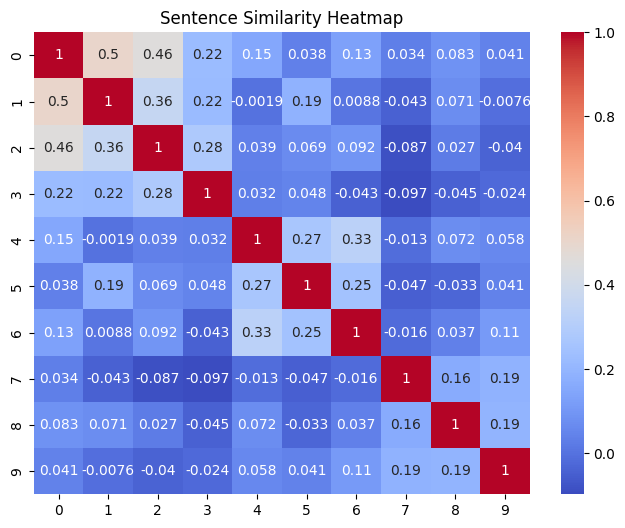

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [7]:
len(sentences)

10

In [8]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

query_similarity = cosine_similarity(query_embedding, embeddings)[0]

top_indices = query_similarity.argsort()[-2:][::-1]

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity Score:", query_similarity[i])
    print()

Sentence: The decision-making during the powerplay shifted the momentum of the innings.
Similarity Score: 0.4084624

Sentence: The middle-order batter executed a perfect sweep shot against the off-spinner.
Similarity Score: 0.38351935

